In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

In [12]:
Poly1 = pd.read_csv('polymer_properties.csv')
Poly1.head(2)


,sample_id,polymer_type,Mn_g_mol,polydispersity_index,glass_transition_Tg_C,crystallinity_pct,density_g_cm3,tensile_strength_MPa,youngs_modulus_GPa,melt_viscosity_Pa_s,melt_flow_index_g_10min,elongation_at_break_pct,degradation_rate_pct_per_day
0,P0001,Nylon6,284417.0,1.712,48.5517,75.9184,1.1902,81.6891,6.3580,91667.9453,40.5787,249.9671,0.9664
1,P0002,PS,203903.0,1.930,95.8213,0.0477,1.0494,49.5844,2.2265,11560.8259,68.1513,2.7296,0.4986


In [23]:
Poly = Poly1.iloc[:,2:]
Poly

,Mn_g_mol,polydispersity_index,glass_transition_Tg_C,crystallinity_pct,density_g_cm3,tensile_strength_MPa,youngs_modulus_GPa,melt_viscosity_Pa_s,melt_flow_index_g_10min,elongation_at_break_pct,degradation_rate_pct_per_day
0,284417.0,1.712,48.5517,75.9184,1.1902,81.6891,6.3580,91667.9453,40.5787,249.9671,0.9664
1,203903.0,1.930,95.8213,0.0477,1.0494,49.5844,2.2265,11560.8259,68.1513,2.7296,0.4986
2,75493.0,1.129,49.7670,79.2638,1.1790,82.2399,5.1844,546.7631,142.9970,25.8041,0.1719
3,202331.0,1.715,74.8774,51.4846,1.4143,64.1271,6.3105,9695.1874,39.4901,66.8060,0.4986
4,60654.0,1.028,-108.4249,67.7406,0.9825,36.2700,1.6331,206.0328,146.8347,8.8245,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
795,33886.0,1.469,97.4591,3.2710,1.0626,39.4402,3.3408,31.8965,541.1139,9.5078,1.8520
796,21057.0,2.694,-117.6170,59.1916,0.9764,21.4140,2.2908,4.0777,566.4291,8.9293,0.0000
797,69422.0,2.628,-112.6180,57.6146,0.9767,37.8459,1.4985,361.0176,125.6406,93.1598,0.5834
798,115710.0,1.505,72.6112,69.2198,1.4309,69.3128,7.3885,2112.6351,78.2497,5.1268,0.6043


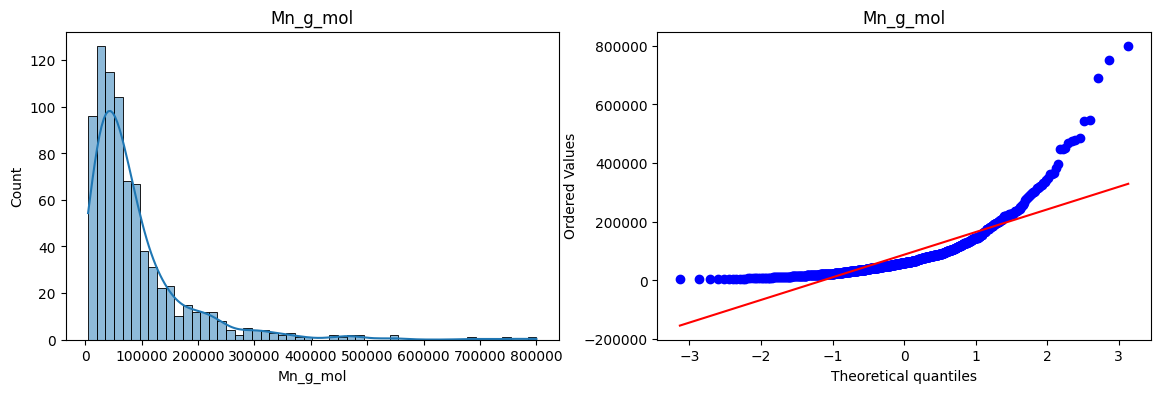

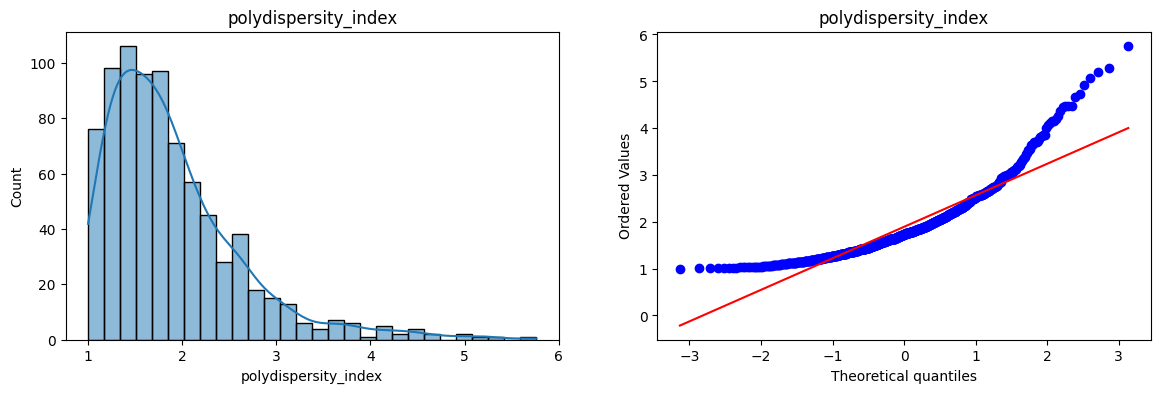

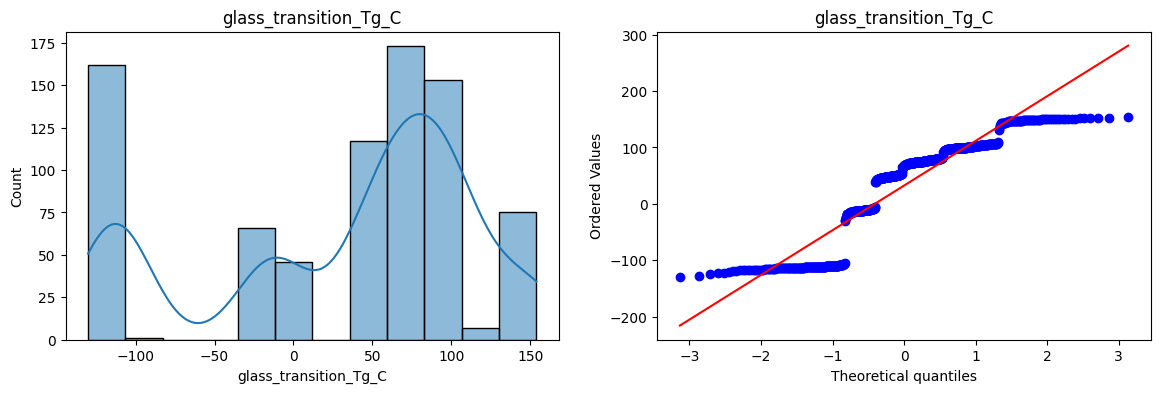

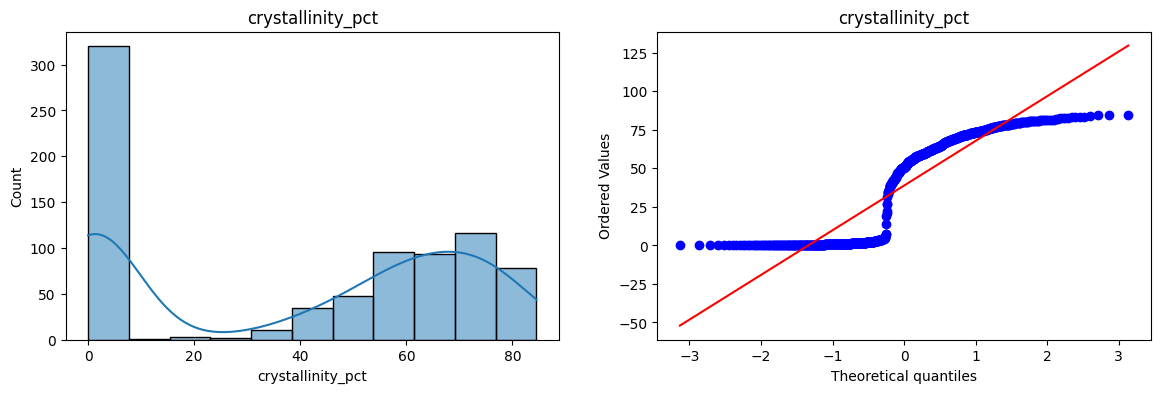

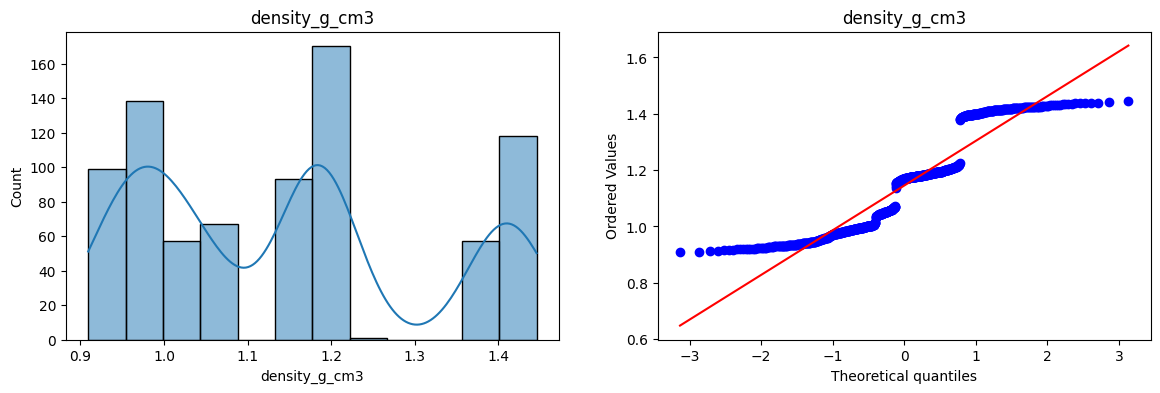

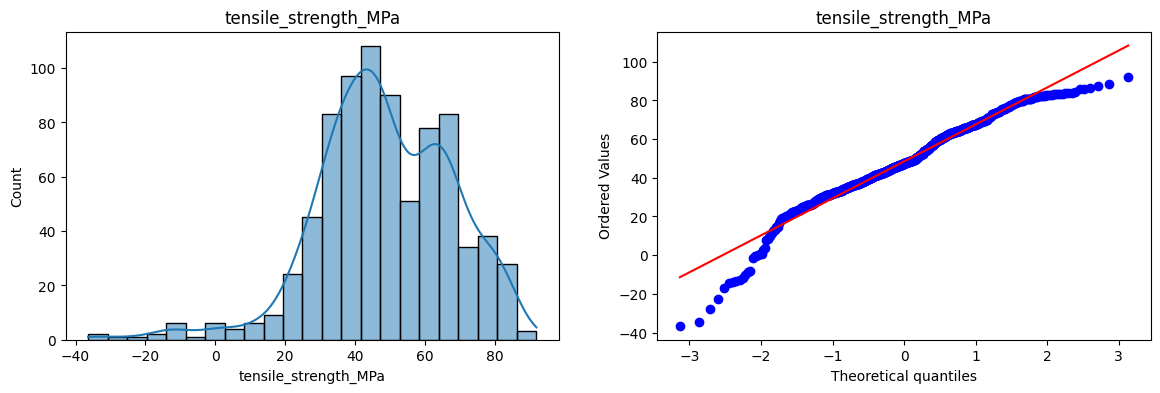

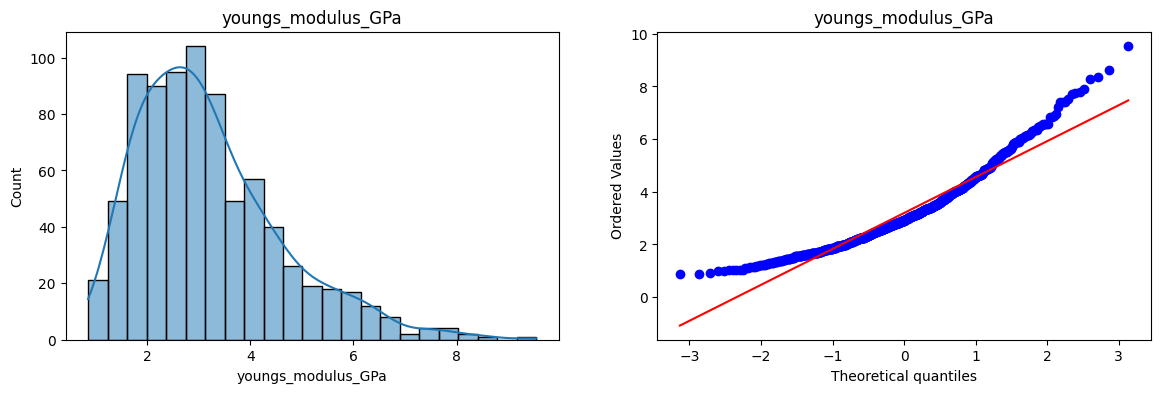

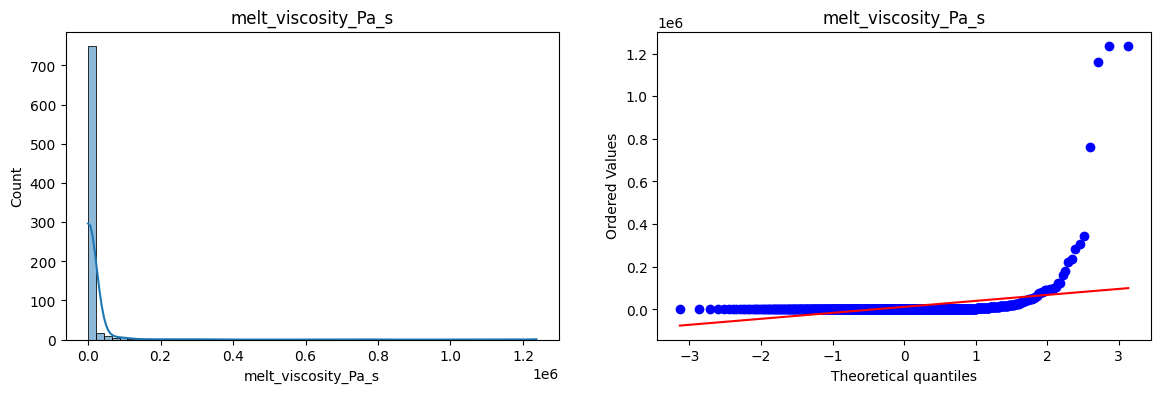

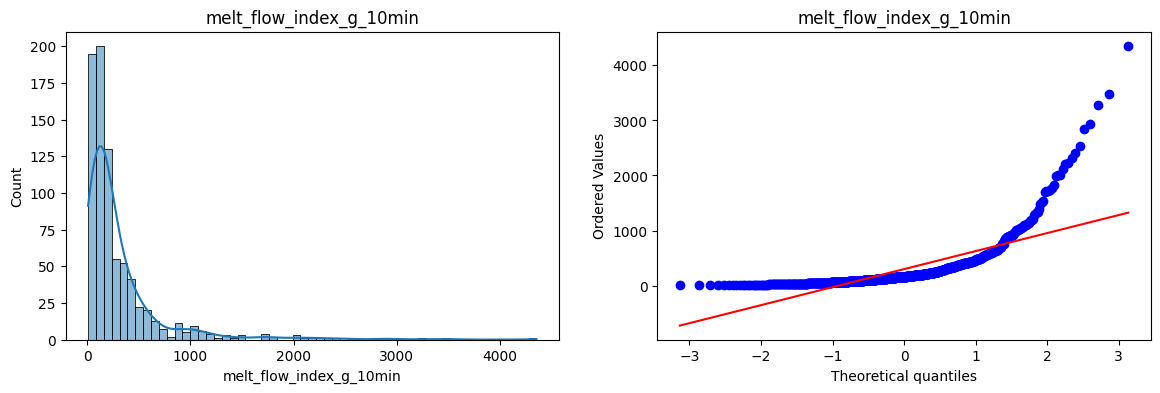

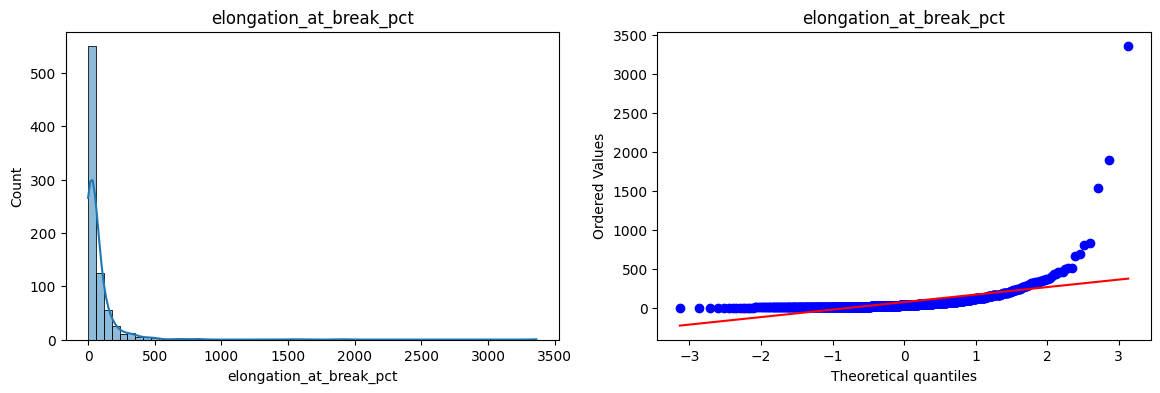

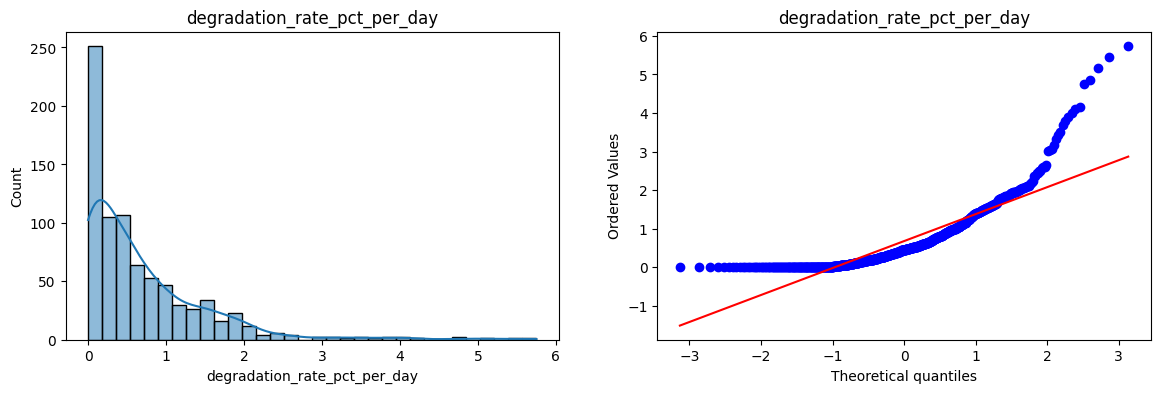

In [24]:
## plotting all the figures at once

for col in Poly.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(Poly[col], kde=True)
    plt.title(col)


    plt.subplot(122)
    stats.probplot(Poly[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()


In [25]:
Poly.isnull().sum()

Mn_g_mol                        0
polydispersity_index            0
glass_transition_Tg_C           0
crystallinity_pct               0
density_g_cm3                   0
tensile_strength_MPa            0
youngs_modulus_GPa              0
melt_viscosity_Pa_s             0
melt_flow_index_g_10min         0
elongation_at_break_pct         0
degradation_rate_pct_per_day    0
dtype: int64

In [34]:
X = Poly.iloc[:, [0, 1, 3, 4, 6, 7]]
Y = Poly['elongation_at_break_pct']
Y

0      249.9671
1        2.7296
2       25.8041
3       66.8060
4        8.8245
         ...   
795      9.5078
796      8.9293
797     93.1598
798      5.1268
799     58.0268
Name: elongation_at_break_pct, Length: 800, dtype: float64

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3)
X_train

,Mn_g_mol,polydispersity_index,crystallinity_pct,density_g_cm3,youngs_modulus_GPa,melt_viscosity_Pa_s
135,383221.0,1.043,42.1706,0.9795,1.4700,97214.9911
630,173925.0,1.172,0.5288,1.1835,2.0979,5800.7286
480,143296.0,3.086,2.3537,1.0510,2.9503,4908.5119
395,27649.0,1.100,4.9998,1.1917,3.3468,15.0990
240,19747.0,1.880,74.1848,1.1787,4.4065,6.4059
...,...,...,...,...,...,...
374,60790.0,1.042,63.2933,1.0004,1.2530,352.7656
171,133233.0,2.545,2.3930,1.1742,1.9320,4972.8180
75,83369.0,1.140,58.2573,0.9404,3.8016,590.8489
609,226014.0,1.899,0.2881,1.0426,3.2930,11737.3342


In [31]:
num = Poly.select_dtypes('number')
print((num <= 0).sum())      # columns with zeros or negatives (unsafe for log / Box-Cox)

Mn_g_mol                          0
polydispersity_index              0
glass_transition_Tg_C           275
crystallinity_pct                 0
density_g_cm3                     0
tensile_strength_MPa             16
youngs_modulus_GPa                0
melt_viscosity_Pa_s               0
melt_flow_index_g_10min           0
elongation_at_break_pct           0
degradation_rate_pct_per_day    123
dtype: int64


In [32]:
Poly.head(1)

,Mn_g_mol,polydispersity_index,glass_transition_Tg_C,crystallinity_pct,density_g_cm3,tensile_strength_MPa,youngs_modulus_GPa,melt_viscosity_Pa_s,melt_flow_index_g_10min,elongation_at_break_pct,degradation_rate_pct_per_day
0,284417.0,1.712,48.5517,75.9184,1.1902,81.6891,6.358,91667.9453,40.5787,249.9671,0.9664


In [39]:
ptr = PowerTransformer(method = 'box-cox')

In [43]:
X_train_ptr = ptr.fit_transform(X_train + 0.000001)
X_test_ptr = ptr.transform(X_test + 0.000001)

X_train_ptr

array([[ 2.04650873, -1.93097873,  0.47127131, -1.04811223, -1.5056473 ,
         1.96297792],
       [ 1.15313697, -1.39790364, -1.348579  ,  0.33497893, -0.72889141,
         1.04478572],
       [ 0.93822211,  1.53111371, -0.97882214, -0.50610263,  0.03235885,
         0.99098951],
       ...,
       [ 0.34580006, -1.51995275,  0.73042335, -1.37709291,  0.60910761,
         0.31481141],
       [ 1.44636508,  0.34477619, -1.45613779, -0.56616168,  0.28122768,
         1.2725447 ],
       [-0.48498976, -0.93376558,  0.79904828, -1.44936474, -0.40143964,
        -0.48633554]], shape=(560, 6))

In [49]:
X_train_ptr2 = pd.DataFrame(X_train_ptr, columns=X_train.columns, index=X_train.index)
X_train_ptr2

,Mn_g_mol,polydispersity_index,crystallinity_pct,density_g_cm3,youngs_modulus_GPa,melt_viscosity_Pa_s
135,2.046509,-1.930979,0.471271,-1.048112,-1.505647,1.962978
630,1.153137,-1.397904,-1.348579,0.334979,-0.728891,1.044786
480,0.938222,1.531114,-0.978822,-0.506103,0.032359,0.990990
395,-0.823529,-1.681508,-0.715715,0.381253,0.318075,-0.831355
240,-1.170288,0.314959,0.942065,0.307612,0.949324,-1.094861
...,...,...,...,...,...,...
374,0.006035,-1.935575,0.801235,-0.882169,-1.848811,0.151701
171,0.857856,1.114909,-0.973679,0.281765,-0.910363,0.995180
75,0.345800,-1.519953,0.730423,-1.377093,0.609108,0.314811
609,1.446365,0.344776,-1.456138,-0.566162,0.281228,1.272545


In [46]:
pd.DataFrame({'cols':X_train.columns, 'box-cox':ptr.lambdas_})

,cols,box-cox
0,Mn_g_mol,0.038788
1,polydispersity_index,-0.807071
2,crystallinity_pct,0.312003
3,density_g_cm3,-0.875281
4,youngs_modulus_GPa,0.063329
5,melt_viscosity_Pa_s,0.007461


In [51]:
lr = LinearRegression()

lr.fit(X_train_ptr, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.81,-7.66,37.89,-8.59, 5.01, 7.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[33.48,28.83,24.89,23.56,15.18, 1.83]"


In [52]:
Y_pred = lr.predict(X_test_ptr)

r2_score(Y_test, Y_pred)

0.03834144370240322

In [57]:
ptr = PowerTransformer(method = 'box-cox')
X_train_ptr = ptr.fit_transform(X_train + 0.0000001)

lr = LinearRegression()

np.mean(cross_val_score(lr, X_train_ptr, Y_train, scoring='r2'))

np.float64(0.08605926476582915)

In [59]:
X_train_ptr2 = pd.DataFrame(X_train_ptr, columns=X_train.columns, index=X_train.index)
X_train_ptr2

,Mn_g_mol,polydispersity_index,crystallinity_pct,density_g_cm3,youngs_modulus_GPa,melt_viscosity_Pa_s
135,2.046509,-1.930979,0.471271,-1.048112,-1.505647,1.962978
630,1.153137,-1.397904,-1.348579,0.334979,-0.728891,1.044786
480,0.938222,1.531114,-0.978822,-0.506103,0.032359,0.990989
395,-0.823529,-1.681508,-0.715715,0.381253,0.318075,-0.831355
240,-1.170288,0.314959,0.942065,0.307612,0.949324,-1.094860
...,...,...,...,...,...,...
374,0.006035,-1.935575,0.801234,-0.882169,-1.848811,0.151701
171,0.857856,1.114909,-0.973679,0.281765,-0.910363,0.995180
75,0.345800,-1.519953,0.730423,-1.377093,0.609108,0.314811
609,1.446365,0.344776,-1.456138,-0.566162,0.281228,1.272545


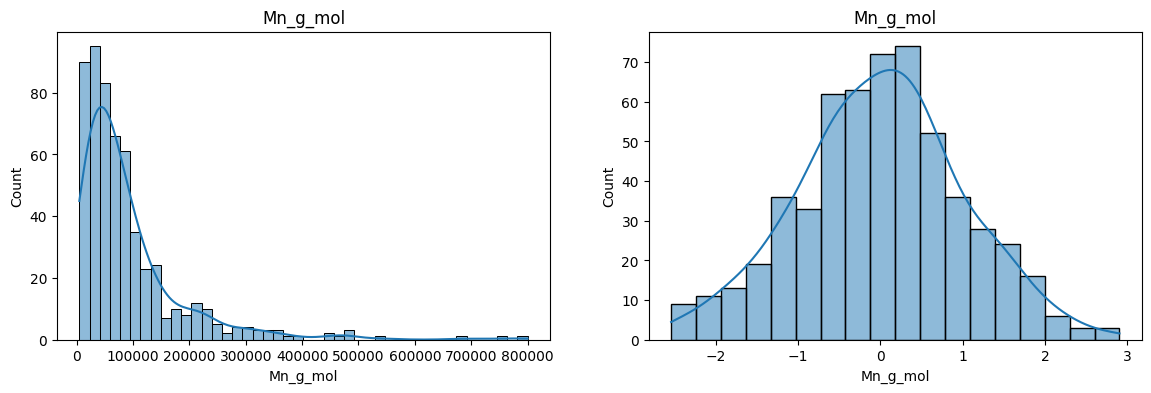

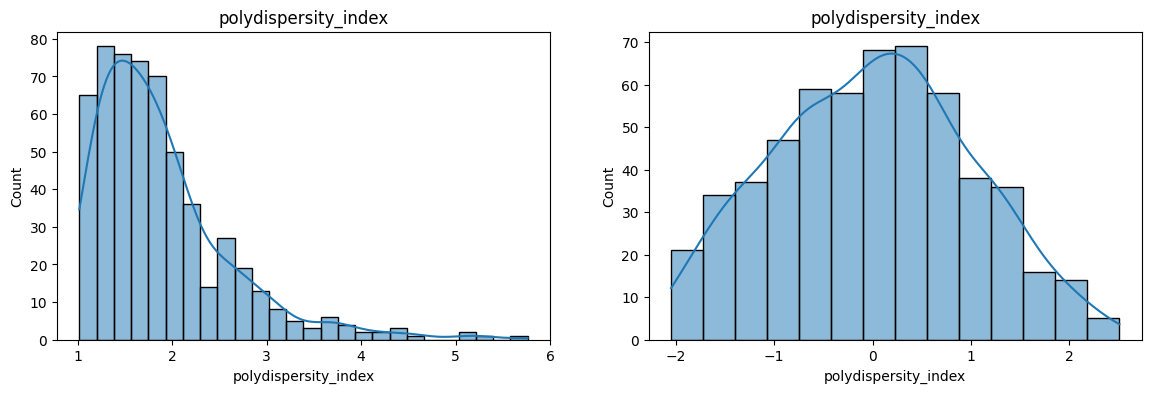

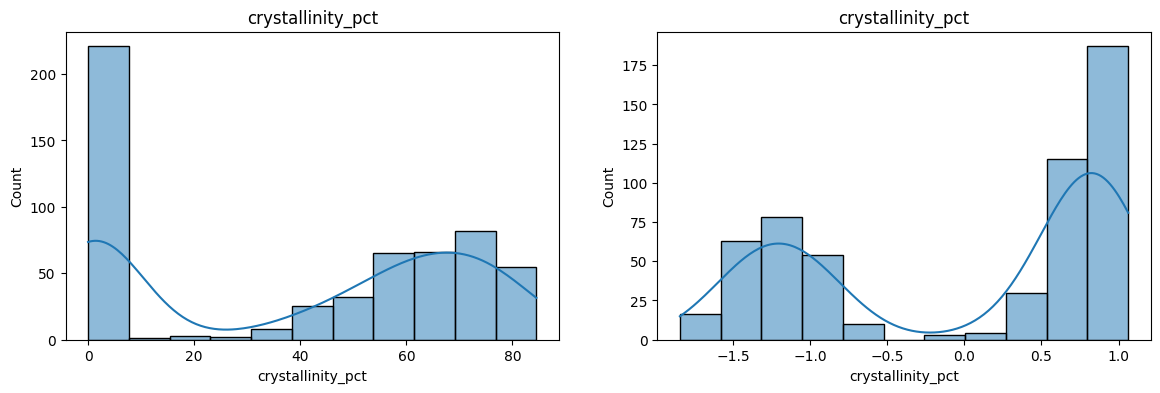

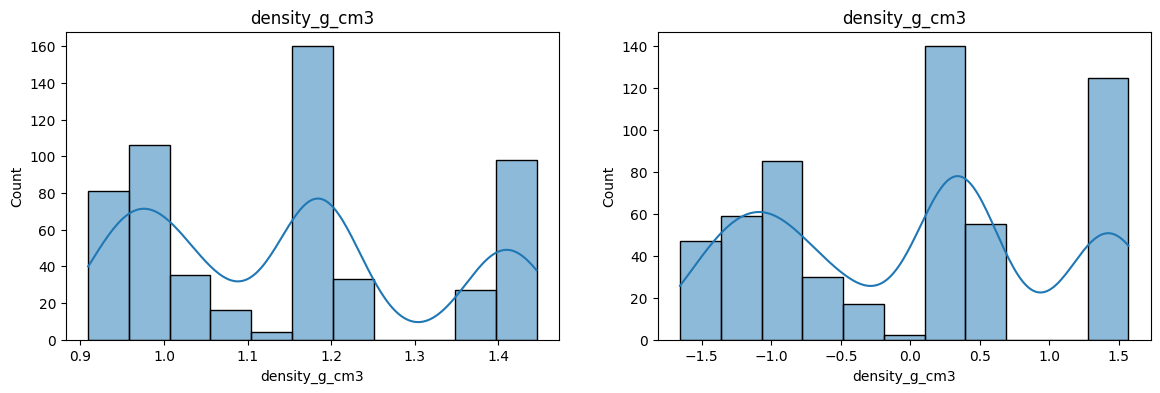

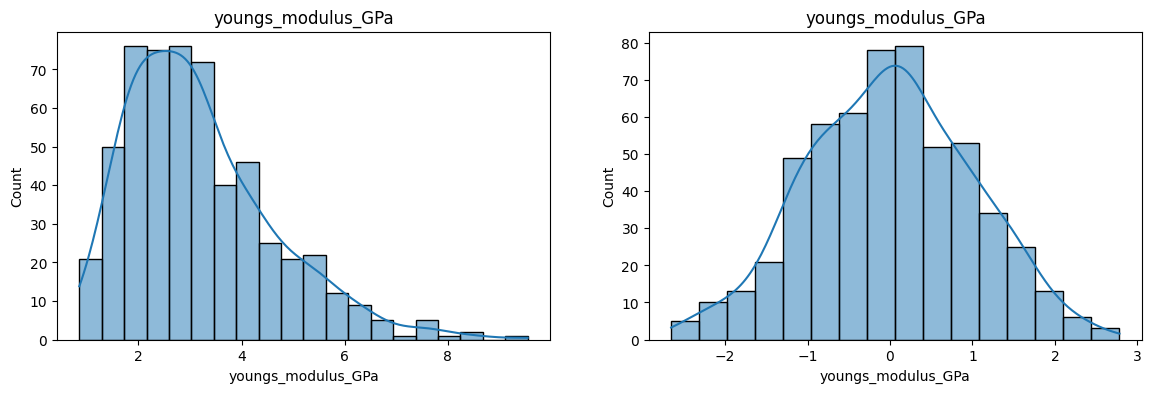

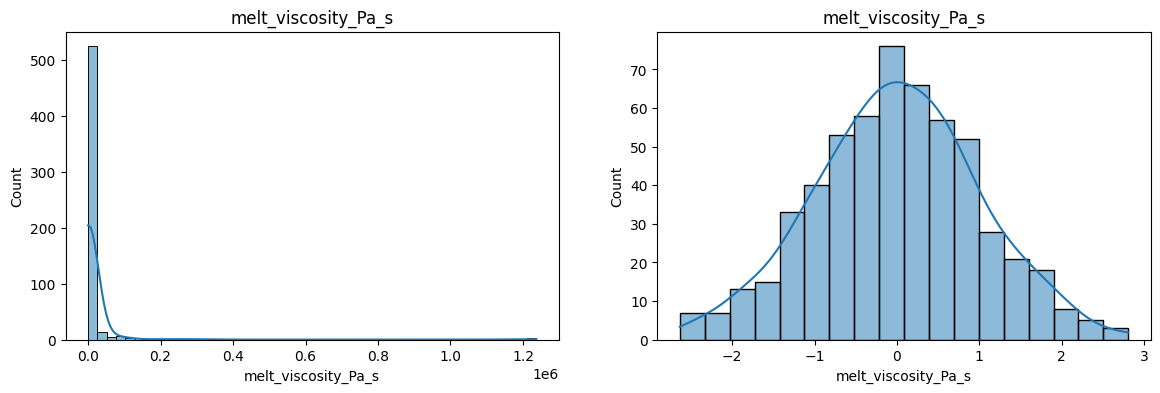

In [60]:
## plotting all the figures at once after box-cox tranformation

for col in X_train_ptr2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)


    plt.subplot(122)
    sns.histplot(X_train_ptr2[col], kde=True)
    plt.title(col)

    plt.show()

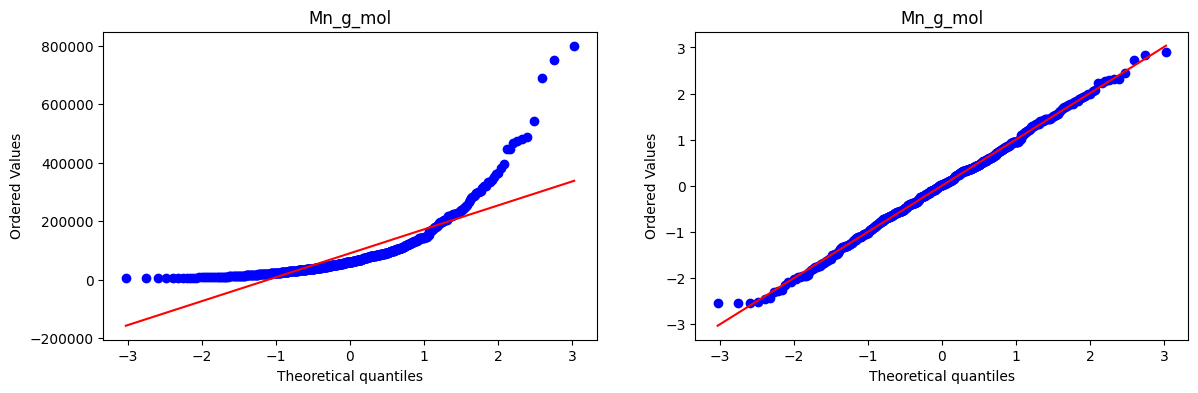

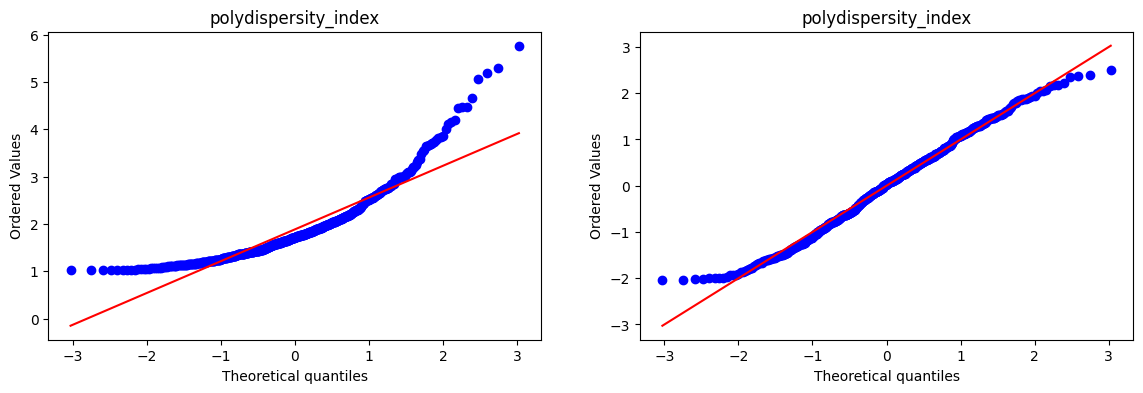

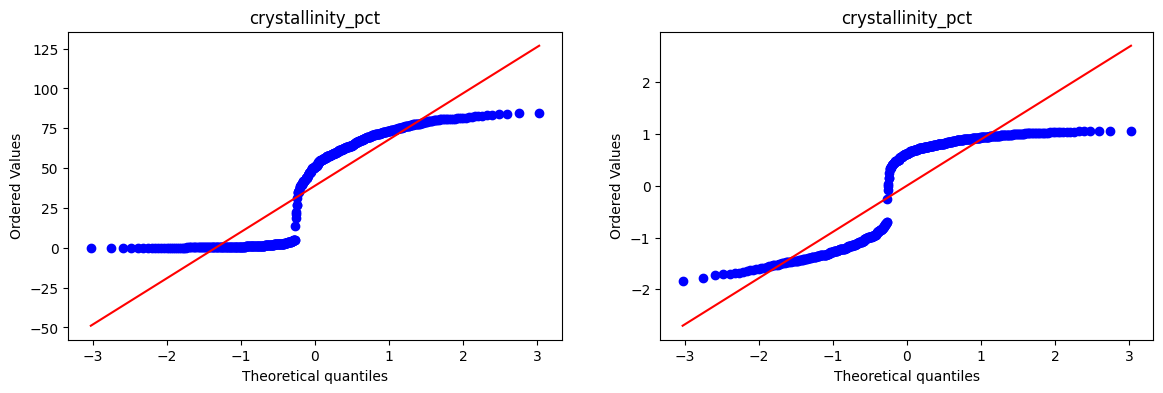

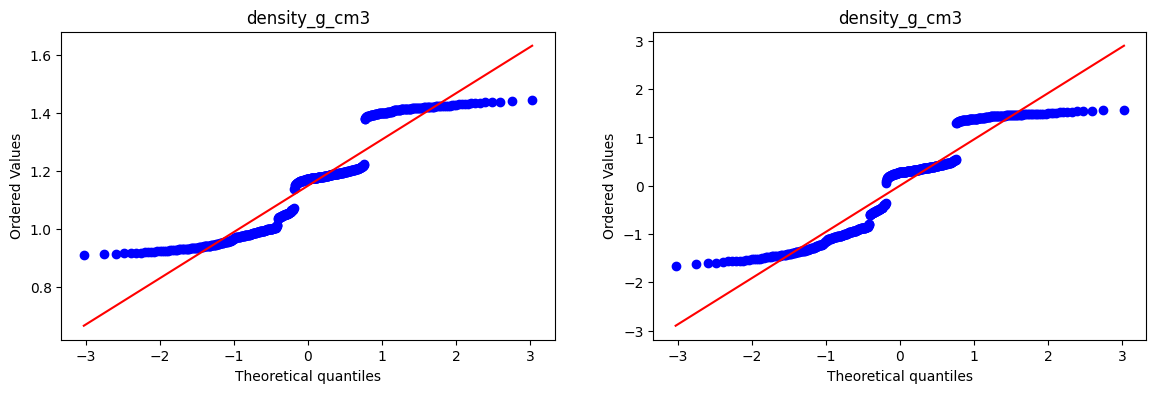

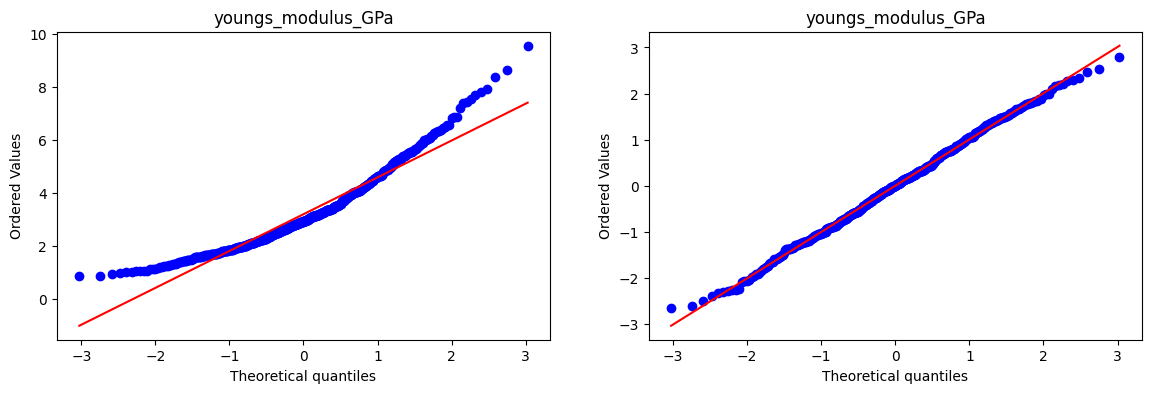

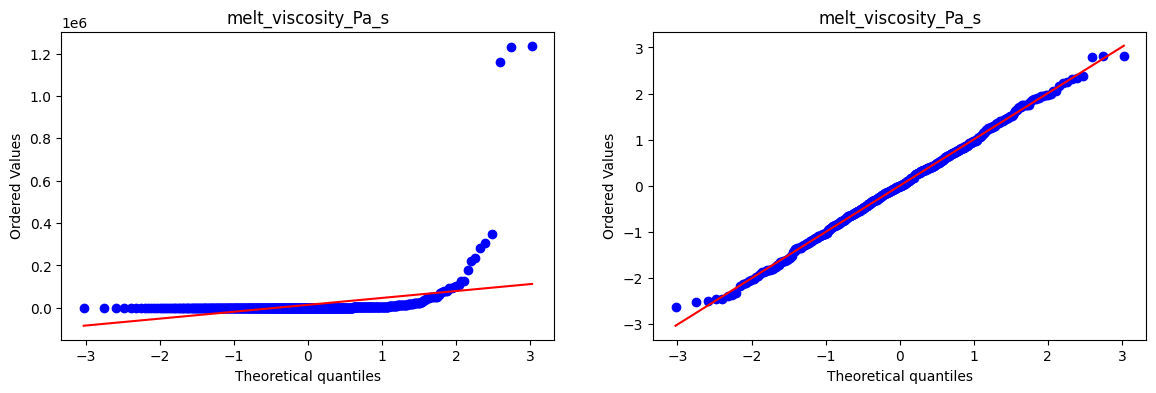

In [62]:
for col in X_train_ptr2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)


    plt.subplot(122)
    stats.probplot(X_train_ptr2[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [74]:
ptr1 = PowerTransformer()
X_train_ptryj = ptr1.fit_transform(X_train)
X_test_ptryj = ptr1.fit_transform(X_test)

lr = LinearRegression()
lr.fit(X_train_ptryj, Y_train)

Y_pred2 = lr.predict(X_test_ptryj)

r2_score(Y_test, Y_pred2)

0.04051973061176839

In [67]:
X_train_ptry = pd.DataFrame(X_train_ptryj, columns=X_train.columns, index=X_train.index)
X_train_ptry

,Mn_g_mol,polydispersity_index,crystallinity_pct,density_g_cm3,youngs_modulus_GPa,melt_viscosity_Pa_s
135,2.046509,-1.930979,0.471271,-1.048112,-1.505647,1.962978
630,1.153137,-1.397904,-1.348579,0.334979,-0.728891,1.044786
480,0.938222,1.531114,-0.978822,-0.506103,0.032359,0.990989
395,-0.823529,-1.681508,-0.715715,0.381253,0.318075,-0.831355
240,-1.170288,0.314959,0.942065,0.307612,0.949324,-1.094860
...,...,...,...,...,...,...
374,0.006035,-1.935575,0.801234,-0.882169,-1.848811,0.151701
171,0.857856,1.114909,-0.973679,0.281765,-0.910363,0.995179
75,0.345800,-1.519953,0.730423,-1.377093,0.609108,0.314811
609,1.446365,0.344776,-1.456138,-0.566162,0.281228,1.272545


In [75]:
pd.DataFrame({'cols':X_train.columns, 'Yeo_Johnson_lambdas':ptr1.lambdas_})


,cols,Yeo_Johnson_lambdas
0,Mn_g_mol,0.041357
1,polydispersity_index,-1.374811
2,crystallinity_pct,0.297578
3,density_g_cm3,-4.347518
4,youngs_modulus_GPa,-0.402291
5,melt_viscosity_Pa_s,-0.027033


In [76]:
ptr1 = PowerTransformer()
X_train_ptr2 = ptr1.fit_transform(X_train + 0.0000001)

lr = LinearRegression()

np.mean(cross_val_score(lr, X_train_ptr2, Y_train, scoring='r2'))

np.float64(0.08752853779037595)

In [83]:
X_train_ptryj2=pd.DataFrame(X_train_ptryj, columns=X_train.columns, index=X_train.index)
X_train_ptryj2

,Mn_g_mol,polydispersity_index,crystallinity_pct,density_g_cm3,youngs_modulus_GPa,melt_viscosity_Pa_s
135,2.046501,-1.876701,0.428907,-1.047764,-1.509073,1.901881
630,1.153141,-1.388531,-1.322059,0.327178,-0.742423,1.078653
480,0.938227,1.551539,-1.069771,-0.514875,0.031659,1.027442
395,-0.823535,-1.651051,-0.833875,0.373919,0.323126,-0.908711
240,-1.170296,0.310086,0.967314,0.299551,0.961464,-1.200846
...,...,...,...,...,...,...
374,0.006036,-1.880812,0.804920,-0.885558,-1.833405,0.182388
171,0.857861,1.133617,-1.065493,0.273470,-0.924591,1.031443
75,0.345804,-1.502276,0.723674,-1.366674,0.618775,0.353544
609,1.446367,0.340820,-1.368608,-0.574347,0.285583,1.291697


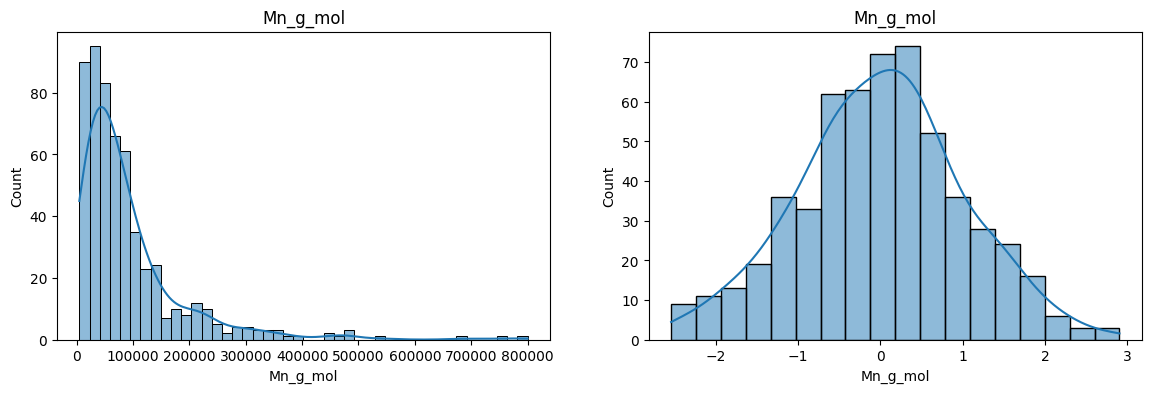

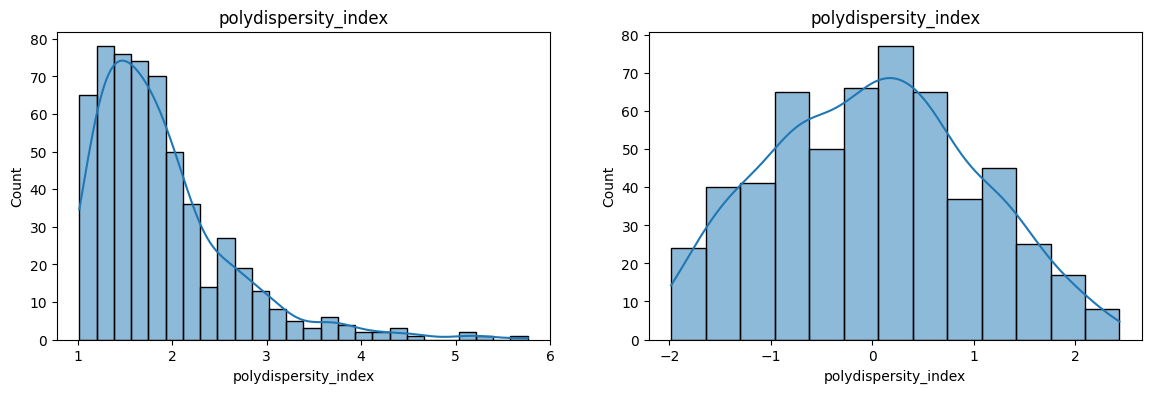

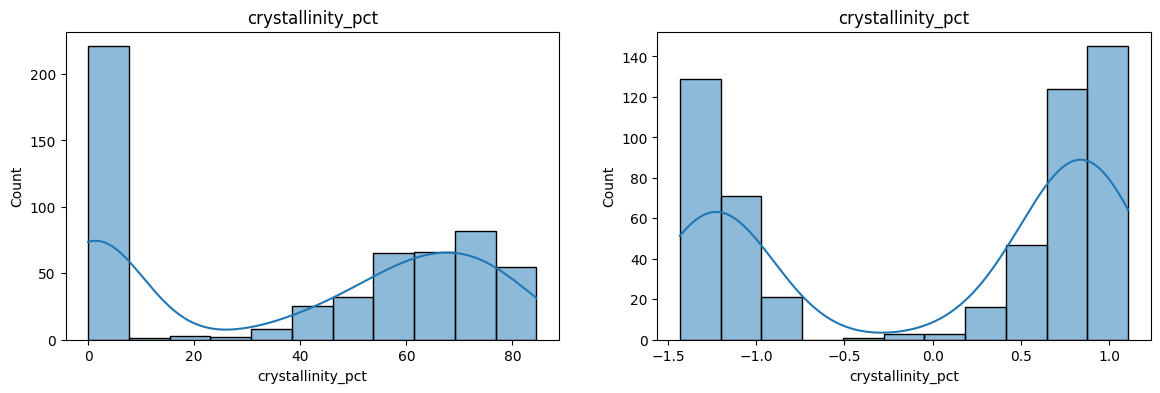

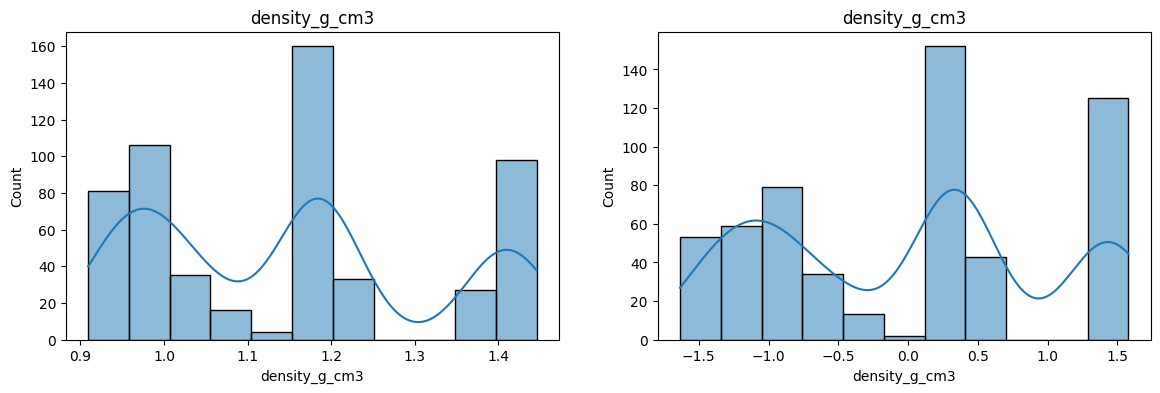

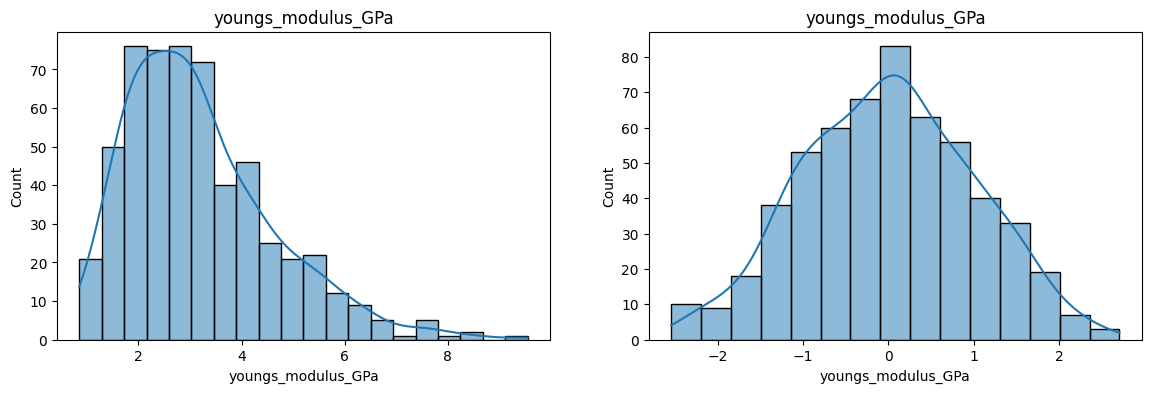

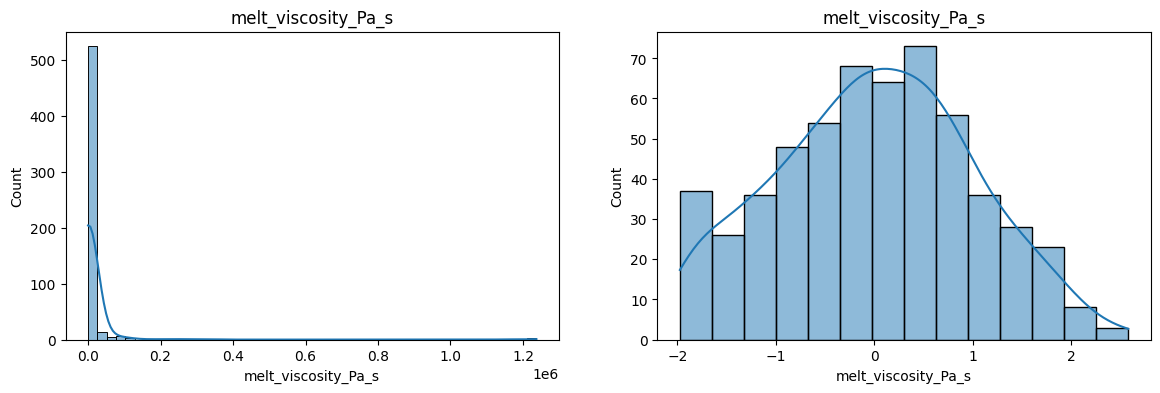

In [85]:
## plotting all the figures at once after Yeo-Johnson tranformation

for col in X_train_ptryj2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)


    plt.subplot(122)
    sns.histplot(X_train_ptryj2[col], kde=True)
    plt.title(col)

    plt.show()

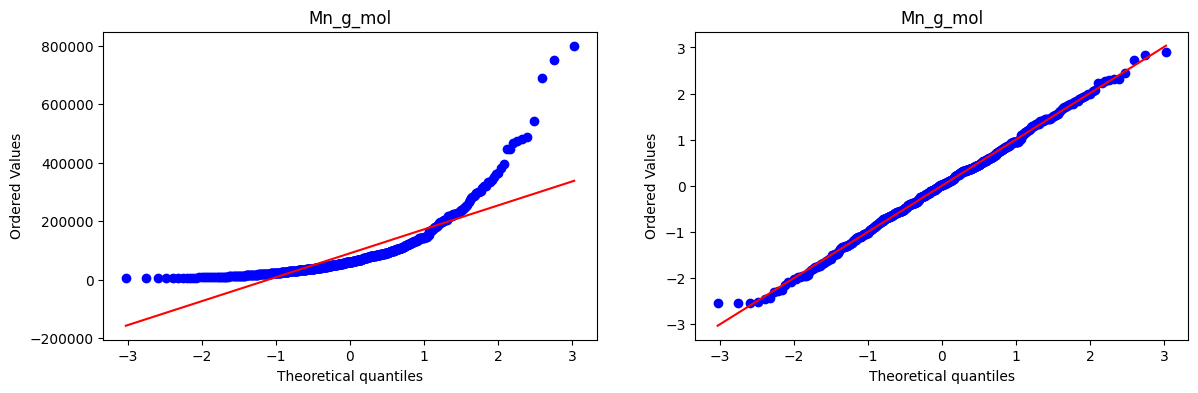

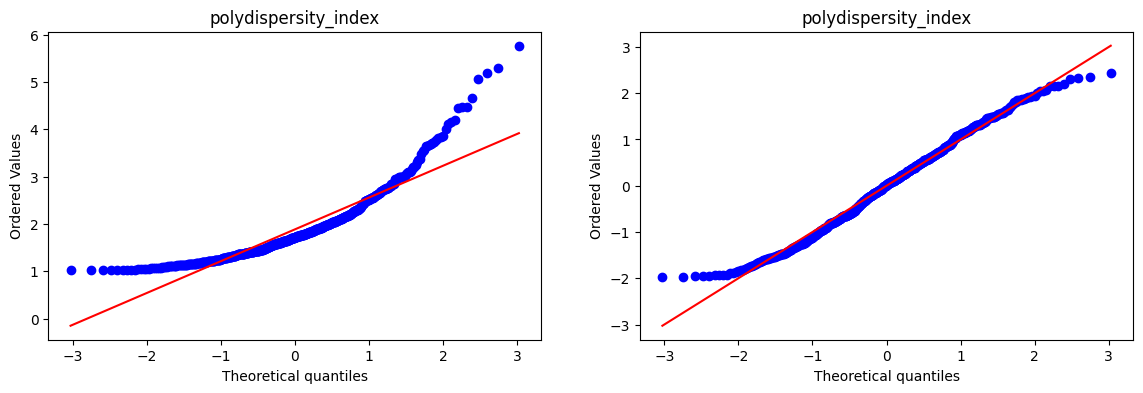

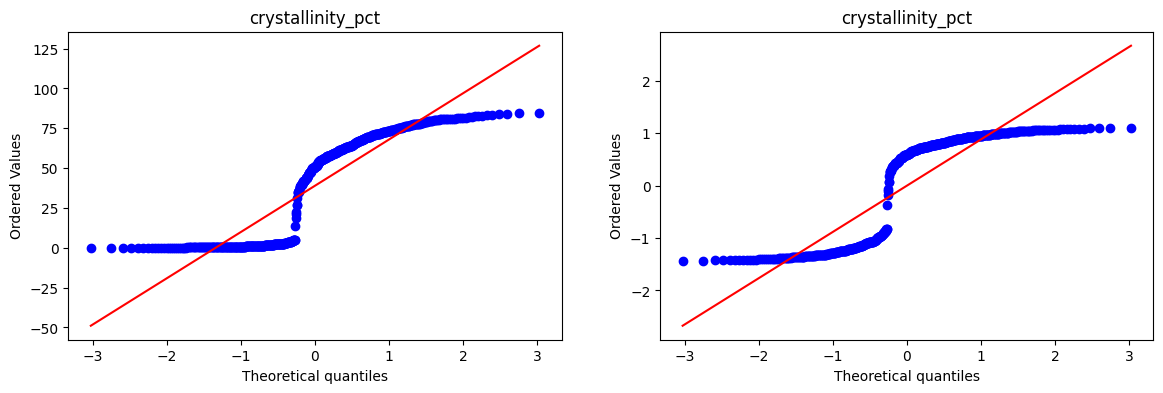

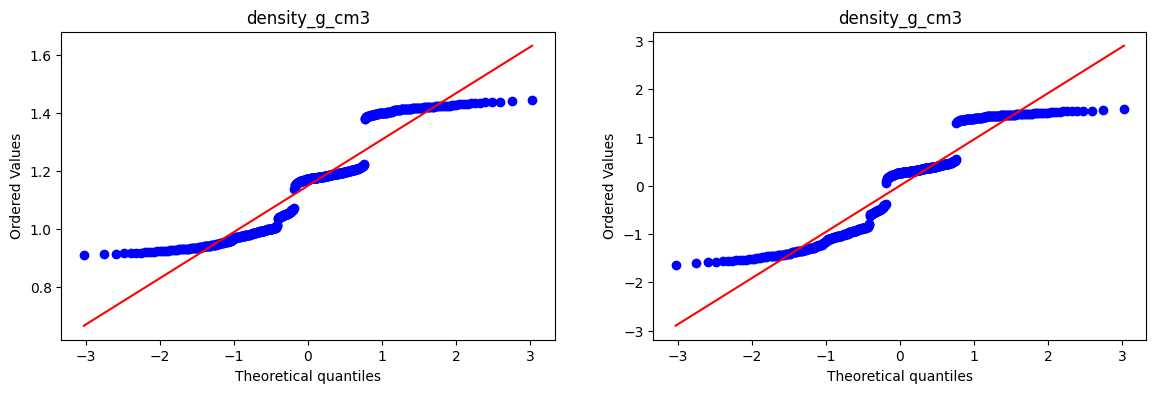

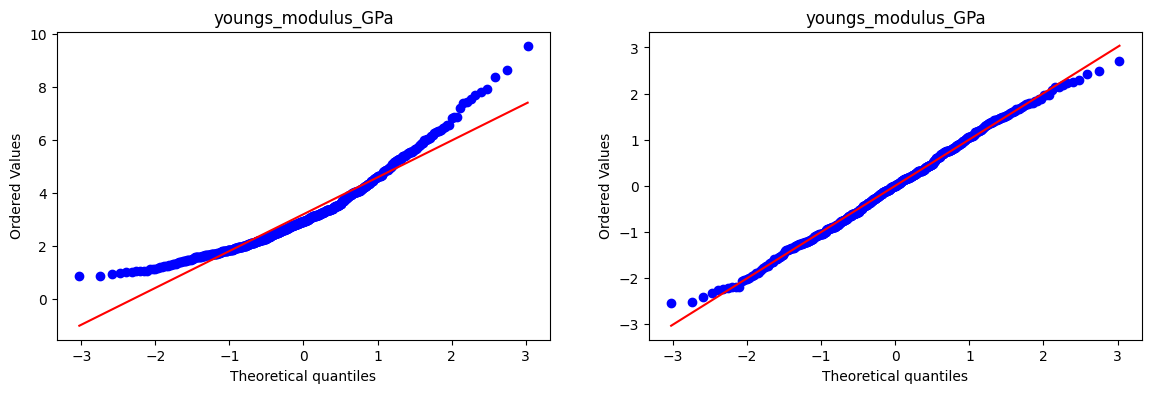

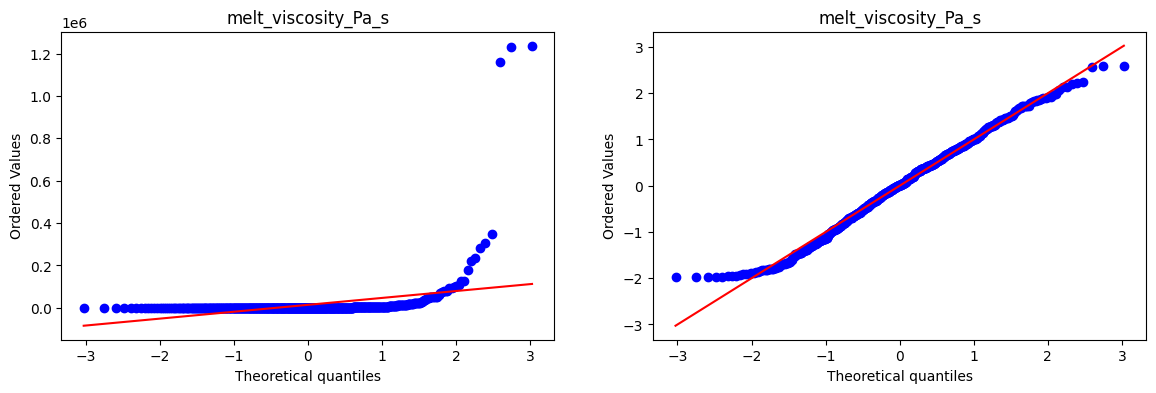

In [86]:
for col in X_train_ptryj2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)


    plt.subplot(122)
    stats.probplot(X_train_ptryj2[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [87]:
pd.DataFrame({'cols':X_train.columns, 'box-cox_lambdas':ptr.lambdas_, 'Yeo_Johnson_lambdas':ptr1.lambdas_})

,cols,box-cox_lambdas,Yeo_Johnson_lambdas
0,Mn_g_mol,0.041381,0.038765
1,polydispersity_index,-0.597679,-1.688408
2,crystallinity_pct,0.273126,0.343348
3,density_g_cm3,-1.988229,-2.258608
4,youngs_modulus_GPa,-0.058967,-0.259541
5,melt_viscosity_Pa_s,0.009708,-0.033001


In [ ]:
Linear regression relies on normal distribution data, where these transformation work well